In [188]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import process_TOMST as pt

#segoe ui font
plt.rcParams['font.family'] = 'Segoe UI'

#### Read lab calibration and TOMST logger data

In [189]:
# read lab calibration data
data_dir=r"W:\VUB\_main_research\data\calibration_TOMST"

#read lab gravimetric measurements
lab_df = pt.read_lab_weights(data_dir, filename='lab_grav_data_dec.csv')

#read TOMST data
loggers, tomst_df = pt.read_TOMST_data(os.path.join(data_dir, 'lab_data/dec_25'), frequency='0.25h')

#read samples and logger combinations
buckets = pd.read_csv(os.path.join(data_dir, 'samples.csv'))

#read pF data from the lab
df_pF = pd.read_excel(os.path.join(data_dir, 'pF_curves_workingsheet.xlsx'), skiprows=1)

#read Kopecky ring lookup table
ring_lookup = pd.read_csv(os.path.join(data_dir, 'kopecky_ring_lookup.csv'))

#### Match lab weights to sensor readings

In [190]:

matched_dfs = {}

for index, row in buckets.iterrows():
    sample = row['bucket']
    logger_id_1 = list(row[['TOMST1']].values)
    logger_id_2 = list(row[['TOMST2']].values)
    sample_logger_1 = [str(i) for i in logger_id_1]
    sample_logger_2 = [str(i) for i in logger_id_2]

    
    #extract data for one sample
    lab_sample = lab_df[lab_df['sample'] == sample][['sample', 'stage', 'weight_kg']].dropna()

    # #extract data for one logger
    df_logger_1 = tomst_df[tomst_df['logger_id'].isin(sample_logger_1)]
    df_logger_2 = tomst_df[tomst_df['logger_id'].isin(sample_logger_2)]

    #MERGE lab and tomst data
    lab_reset_df = lab_sample.reset_index().rename(columns={'index': 'datetime'})
    tomst_reset_df_1 = df_logger_1.reset_index().rename(columns={'index': 'datetime'})
    tomst_reset_df_2 = df_logger_2.reset_index().rename(columns={'index': 'datetime'})

    matched_valid_1 = pd.merge_asof(
        lab_reset_df,
        tomst_reset_df_1,
        on="datetime",
        direction="nearest"
    )
    matched_valid_2 = pd.merge_asof(
        lab_reset_df,
        tomst_reset_df_2,
        on="datetime",
        direction="nearest"
    )

    matched_df_1 = matched_valid_1.set_index("datetime")
    matched_df_1['raw_sm_diff'] = matched_df_1['rawsm'].diff().abs()
    matched_df_1['weight_diff'] = matched_df_1['weight_kg'].diff().abs()
    matched_df_2['raw_sm_diff'] = matched_df_2['rawsm'].diff().abs()
    matched_df_2['weight_diff'] = matched_df_2['weight_kg'].diff().abs()

    matched_df_2 = matched_valid_2.set_index("datetime")
    matched_dfs[sample] = {
    "logger1": matched_df_1,
    "logger2": matched_df_2
}

<Axes: xlabel='datetime'>

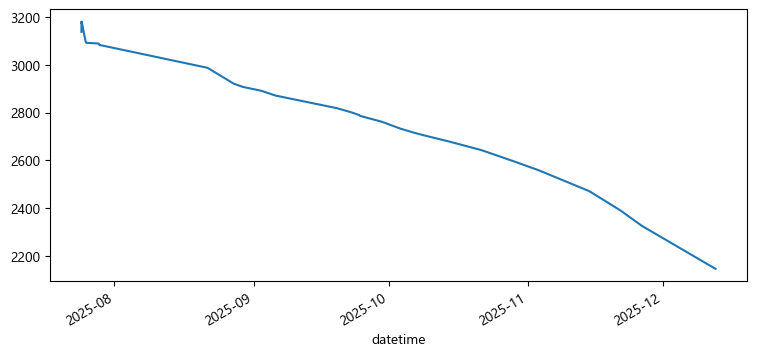

In [191]:
fig, ax = plt.subplots(figsize=(9, 4))
#df1['weight_kg'].plot()
df1['rawsm'].plot()
#plt.ylim(30, 40)

Text(0, 0.5, 'Gravimetric water content (kg)')

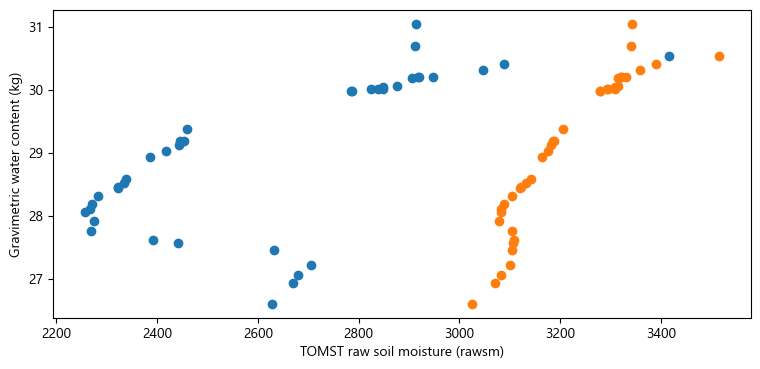

In [222]:
fig, ax = plt.subplots(figsize=(9, 4))
sample = 'MDW 438'

df1 = matched_dfs[sample]['logger2']
df2 = matched_dfs[sample]['logger1']
ax.scatter(df1['rawsm'], df1['weight_kg'], label='Logger 2')
ax.scatter(df2['rawsm'], df2['weight_kg'], label='Logger 1')
ax.set_xlabel('TOMST raw soil moisture (rawsm)')
ax.set_ylabel('Gravimetric water content (kg)')
# ax.set_ylim(1500, 3600)

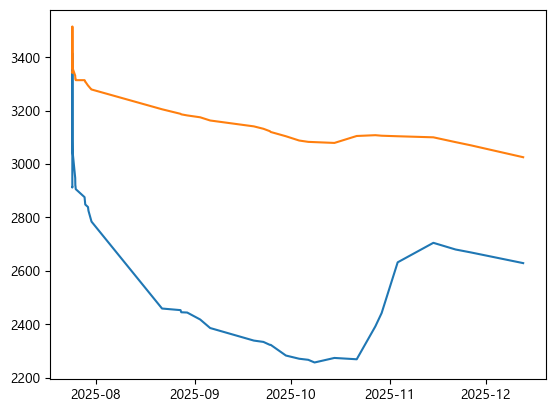

In [230]:
plt.plot(matched_dfs['MDW 438']['logger2']['rawsm'])
plt.plot(matched_dfs['MDW 438']['logger1']['rawsm'])

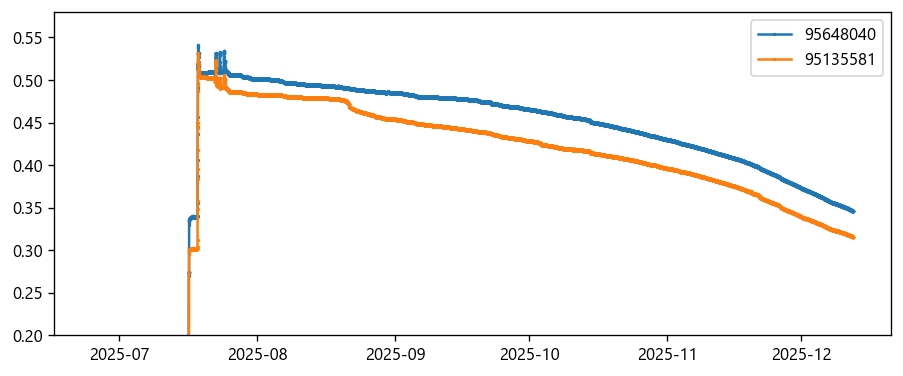

In [193]:
sample_loggers = ['95648040', '95135581']

plt.figure(figsize=(9, 3.5), dpi=120)

for sample_logger in sample_loggers:
    sample_df_sm = tomst_df[tomst_df['logger_id'] == sample_logger]['rawsm']

    #sample calibration
    sample_df_cal = -0.0000000134*sample_df_sm**2 + 0.000249622*sample_df_sm - 0.157889

    #plot gradient of weight over time
    plt.plot(sample_df_cal, label=sample_logger, marker='o', markersize=1)
    plt.ylim(0.20, 0.58)
    plt.legend()

### Construct calibration curves

In [ ]:
kopecky_buckets_merged = df_pF.merge(
    ring_lookup,
    on="Kopecky ring #",
    how="left"
)

#format horizon column as string
kopecky_buckets_merged['horizon'] = kopecky_buckets_merged['horizon'].astype(str)


In [231]:
kopecky_buckets_merged

,Kopecky ring #,Dry volume weight (g/cm³),TPV (cm³/cm³),vwc_0,vwc_1.5,vwc_2,vwc_2.3,vwc_2.8,vwc_3.4,vwc_4.2,bucket_id,horizon
0,591,1.543460,0.416263,0.422900,0.371020,0.341010,0.317620,0.221510,0.116565,0.073659,mdw359,1
1,615,1.314460,0.502871,0.440600,0.353140,0.324090,0.295990,0.198900,0.083633,0.053766,mdw359,1
2,59,1.128750,0.573106,0.481750,0.329920,0.285636,0.252307,0.167943,0.069493,0.044765,mdw359,2
3,92,1.367160,0.482939,0.439280,0.343190,0.310500,0.283550,0.193440,0.096430,0.062571,mdw359,2
4,224,1.227410,0.535793,0.432580,0.343050,0.312260,0.282480,0.195310,0.083936,0.053287,mdw359,1
5,538,1.418220,0.463628,0.400040,0.345280,0.315750,0.289040,0.194640,0.102857,0.065387,mdw359,2
6,4,0.462219,0.825189,0.679656,0.409708,0.328813,0.298344,0.269500,0.070966,0.079569,mdw207,0
7,569,0.742180,0.719307,0.659360,0.489240,0.335390,0.292530,0.267800,0.073826,0.070165,mdw207,0
8,93,0.288611,0.890847,0.733956,0.437367,0.342733,0.313811,0.286789,0.072096,0.060301,mdw207,0
9,289,0.889550,0.663572,0.624220,0.553580,0.515760,0.471450,0.363070,0.085664,0.065444,mdw359,0


In [215]:
### groupby bucket to get mean of pF values per bucket
kopecky_buckets_grouped = kopecky_buckets_merged.groupby('bucket_id').mean(numeric_only=True).reset_index().drop(columns=['Kopecky ring #'])

In [232]:
ring_lookup

,Kopecky ring #,bucket_id,horizon
0,4,mdw207,0
1,10,mdw207,1
2,31,mdw414,2
3,46,mdw392,2
4,56,mdw438,2
5,58,mdw438,1
6,59,mdw359,2
7,65,mdw438,1
8,70,mdw-x-358,0
9,73,mdw392,1


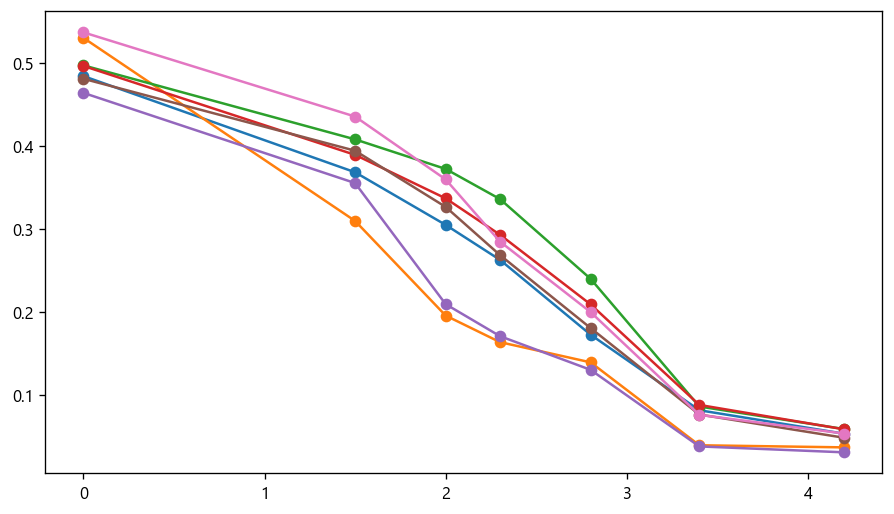

In [219]:
#plot pF curves for each bucket
plt.figure(figsize=(9, 5), dpi=120)
for index, row in kopecky_buckets_grouped.iterrows():
    bucket_id = row['bucket_id']
    plt.plot(
        [0, 1.5, 2, 2.3, 2.8, 3.4, 4.2],
        [
            row['vwc_0'],
            row['vwc_1.5'],
            row['vwc_2'],
            row['vwc_2.3'],
            row['vwc_2.8'],
            row['vwc_3.4'],
            row['vwc_4.2']
        ],
        label=f'Bucket {bucket_id}',
        marker='o'
    )